In [67]:
import cv2 as cv
import util as utils

In [69]:
video_path = "material/focus_video.mov"

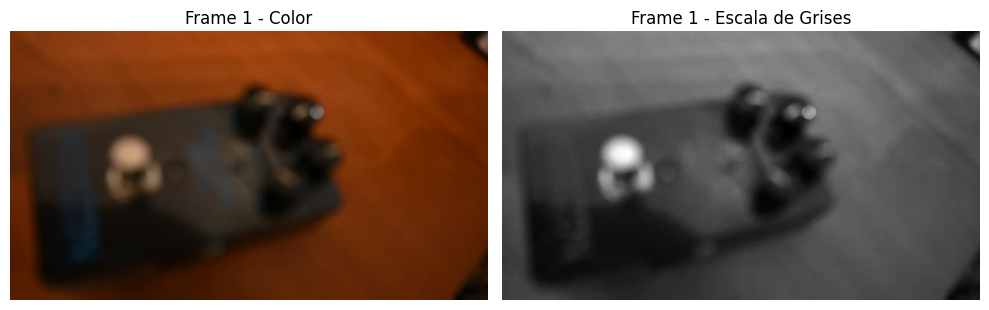

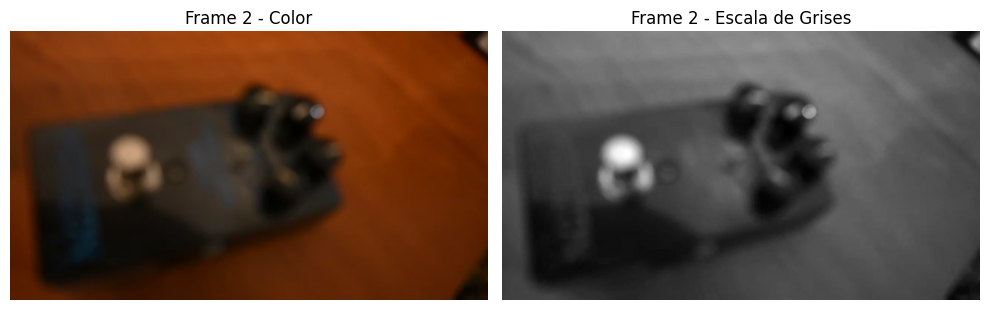

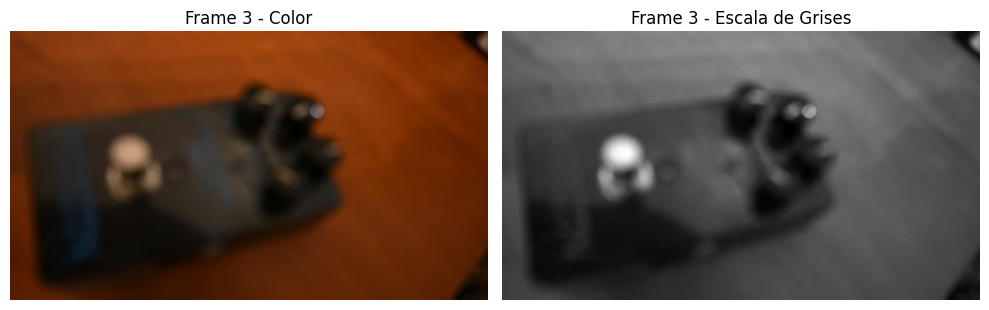

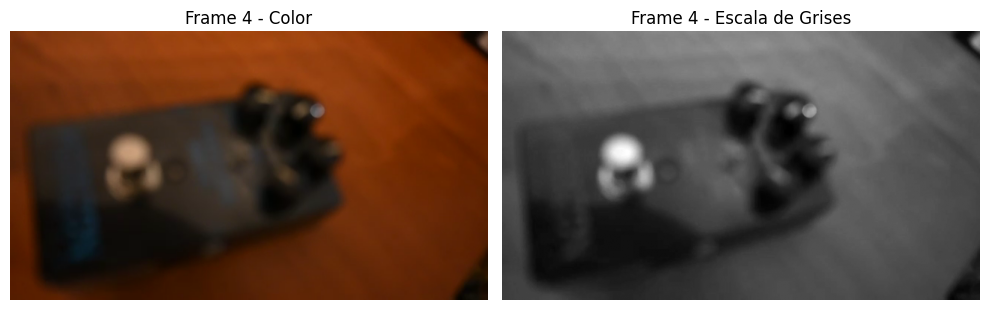

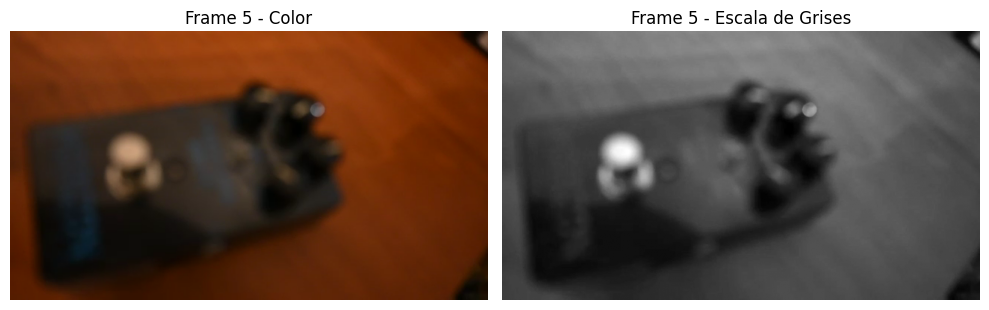

In [70]:
utils.show_n_frames(video_path, 5)

In [71]:
captura_video = cv.VideoCapture(video_path)

if captura_video.isOpened():
    # Obtiene dimensiones del video
    frame_width = int(captura_video.get(cv.CAP_PROP_FRAME_WIDTH))
    frame_height = int(captura_video.get(cv.CAP_PROP_FRAME_HEIGHT))
    new_width = frame_width // 2
    new_height = frame_height // 2

    # Obtiene la tasa de cuadros por segundo
    fps = int(captura_video.get(cv.CAP_PROP_FPS))
    delay = int(600 / fps)

    while True:
        ret, frame = captura_video.read()
        if not ret:
            break

        # Redimensionar frame a la mitad
        frame_resized = cv.resize(frame, (new_width, new_height))

        # Mostrar frame
        cv.imshow("Video", frame_resized)

        # Salir con la tecla 'q'
        if cv.waitKey(delay) & 0xFF == ord("q"):
            break

    # Liberar recursos
    captura_video.release()
    cv.destroyAllWindows()
    cv.waitKey(1)

CSV exportado a: material/fm/frecuencia_fm.csv
Gráfico guardado como: material/fm/frecuencia_fm.png


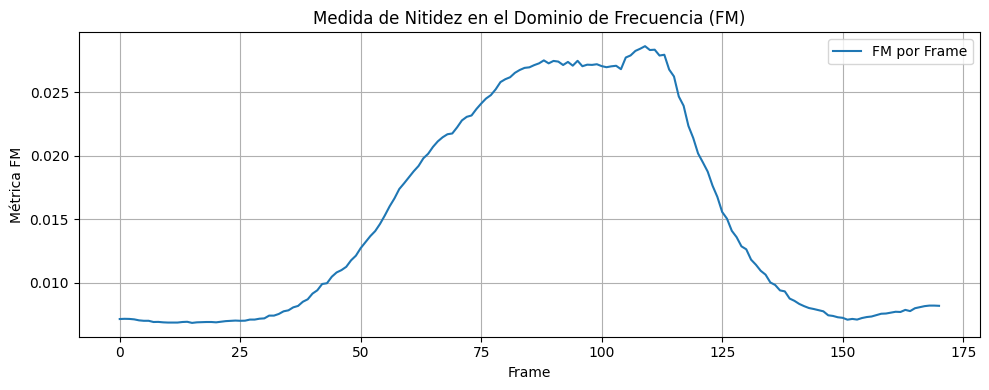

Mostrando los 3 frames con menor FM:


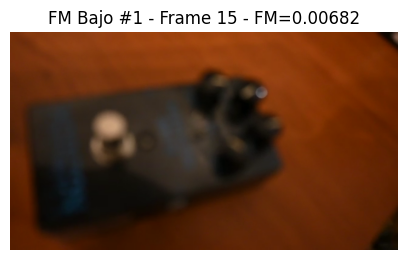

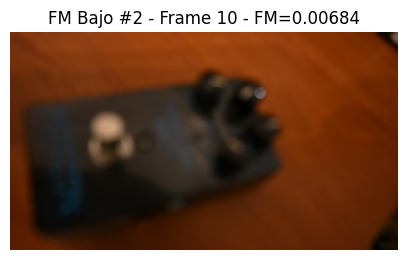

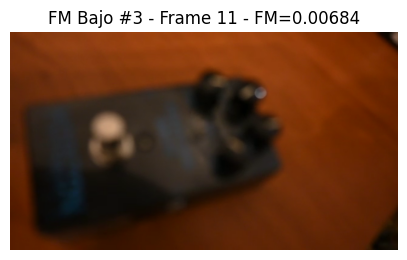

Mostrando los 3 frames con mayor FM:


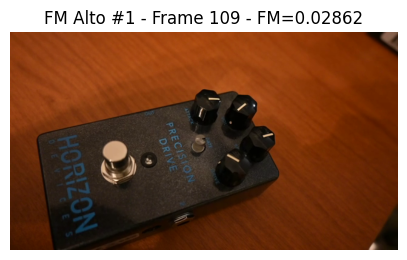

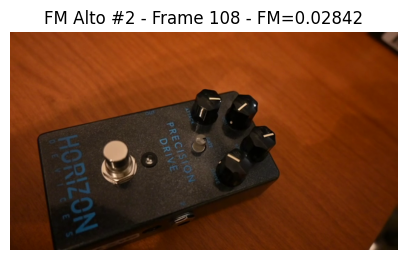

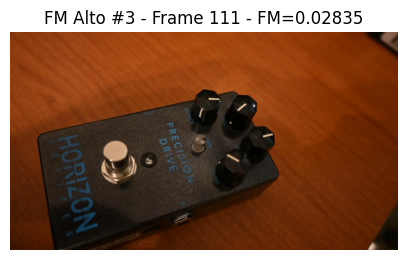

In [72]:
fm_values, frames_processed = utils.process_video(video_path)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, "material/fm")
    utils.show_extreme_frames(fm_values, frames_processed, n=3)

# Ejercicio 3
Consigna: Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados.
N y M son valores arbitrarios; probar con varios valores (3×3, 7×5, etc.) — al menos 3 configuraciones.

### 🔍 Punto 3 – Matriz de enfoque (FM map N × M)

**Procedimiento**

1. **Segmentación** Divido cada frame en una grilla *N × M* (p. ej., 3×3, 5×5, 7×5).  
2. **Cálculo en cada bloque**  
    - Transformada de Fourier:  
        $$F = \mathcal{F}\{I\}$$  
    - Centración:  
        $$F_c = \operatorname{fftshift}(F)$$  
    - Módulo espectral:  
        $$A_F = |F_c|$$  
    - Umbral fijo:  
        $$\mathrm{thres} = \frac{\max(A_F)}{1000}$$  
    - Conteo de altas frecuencias:  
        $$
        TH = \bigl|\{\,p \in A_F \;\big|\; p > \mathrm{thres}\}\bigr|
        $$
 
    - Métrica final:  
        $$FM = \frac{TH}{H \times W}$$  


3. **Visualización** Represento los valores en un mapa de calor:  
   * **Tonos claros → FM alta → zona nítida**  
   * **Tonos oscuros → FM baja → zona desenfocada o con poco detalle**

---

#### Elección de la resolución de grilla

| Resolución | Caso de uso recomendado |
|------------|-------------------------|
| **3×3 / 5×5** | Diagnóstico rápido: identifica el cuadrante enfocado sin ruido excesivo. |
| **≥ 7×5** | Localización precisa dentro de la zona nítida; tolera algo más de variabilidad numérica. |

---

## Analisis del primer frame

In [73]:
cap = cv.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

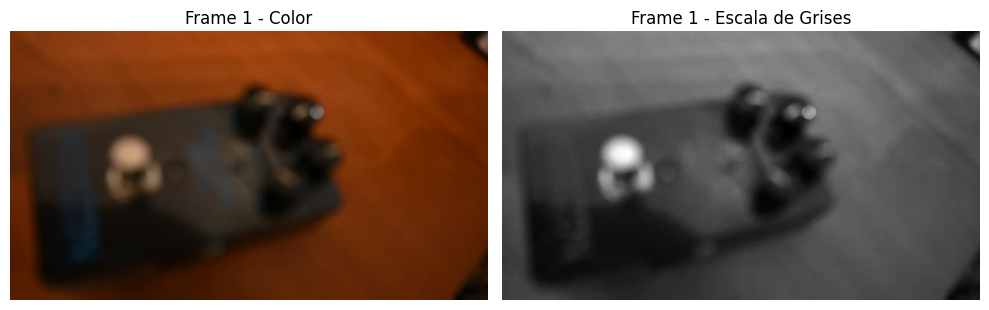

In [74]:
utils.show_n_frames(video_path, 1)

In [75]:
grid_configs = [
    (3, 3),
    (7, 5),
    (5, 5),
]

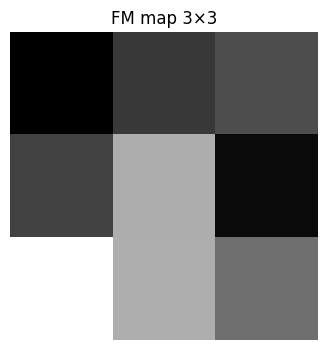

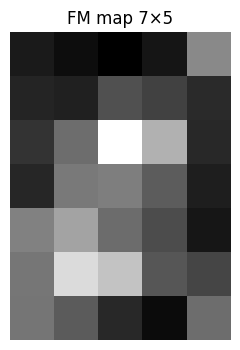

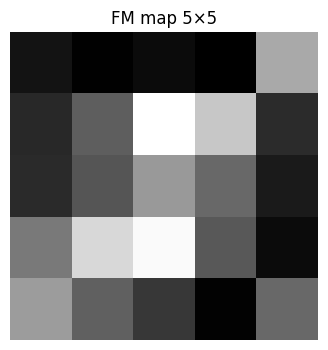

In [76]:
for rows, cols in grid_configs:
    fm_map = utils.measure_grid_focus_map(frame_gray, rows, cols)
    utils.show_image(fm_map, title=f"FM map {rows}×{cols}")

In [ ]:
fm_map = utils.measure_grid_focus_map(frame_gray, 3, 3)
print(fm_map)

[[0.01463224 0.02183099 0.02433801]
 [0.0228482  0.0362676  0.01600467]
 [0.04663537 0.03638498 0.02838785]]


## Comparacion con el frame 109

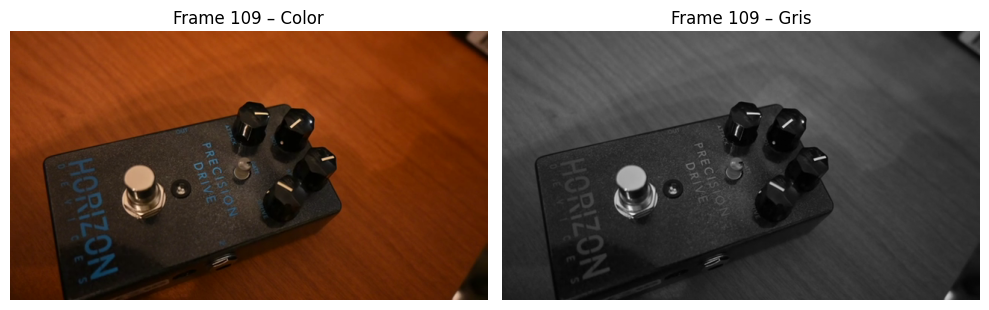

In [ ]:
frame_109_gray = utils.show_frame(video_path, 109, to_gray=True)

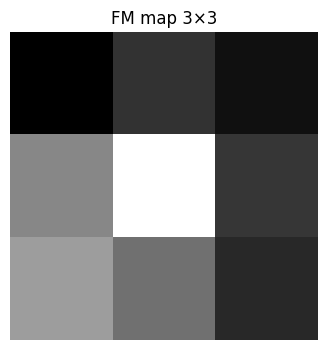

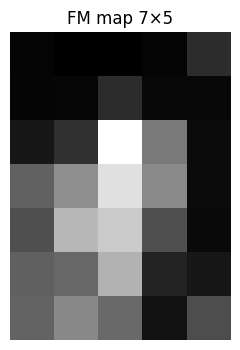

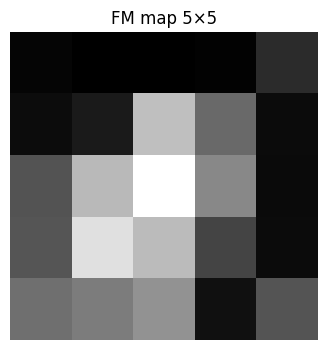

In [79]:
for rows, cols in grid_configs:
    fm_map = utils.measure_grid_focus_map(frame_109_gray, rows, cols)
    utils.show_image(fm_map, title=f"FM map {rows}×{cols}")

In [ ]:
fm_map = utils.measure_grid_focus_map(frame_109_gray, 3, 3)
print(fm_map)

[[0.01271518 0.07496088 0.03309969]
 [0.18043819 0.32871675 0.08049066]
 [0.20672926 0.15105633 0.06417446]]
